## Step 0: Installing and importing required libraries
Before any coding, it is crucial to install and import all the necessary libraries.

In [ ]:
# Install required libraries
!pip install -r requirements.txt

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
import kagglehub
import shutil, os
warnings.filterwarnings('ignore')

## Step 1: Pre-processing and cleaning our dataset
Before we begin training our machine, it is crucial to feed it a clean and pre-processed dataset.

### Step 1.1: Data profiling
We need to know the "face" of our dataset to evaluate the necessary data cleaning and preprocessing measures.

In [42]:
# Downloading the dataset
path = kagglehub.dataset_download ("shivamb/machine-predictive-maintenance-classification")
print(f" Downloaded to: {path}")

# Copy the dataset files to the project directory
destination = os.getcwd()
shutil.copytree(path, os.path.join (destination,"raw"), dirs_exist_ok = True)

# Reading the dataset
df = pd.read_csv('raw\predictive_maintenance.csv')

print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe(include='all'))

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

 Downloaded to: C:\Users\LENOVO\.cache\kagglehub\datasets\shivamb\machine-predictive-maintenance-classification\versions\1
Shape: (10000, 10)

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure



Data types:


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                   str
dtype: object


Missing values:


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


Statistical summary:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN



Unique values per column:
UDI: 10000 unique values
Product ID: 10000 unique values
Type: 3 unique values
Air temperature [K]: 93 unique values
Process temperature [K]: 82 unique values
Rotational speed [rpm]: 941 unique values
Torque [Nm]: 577 unique values
Tool wear [min]: 246 unique values
Target: 2 unique values
Failure Type: 6 unique values


### Step 1.2: Missing data detection
Therefore, in order to identify the missing data, we will generate a heat map using our dataset.

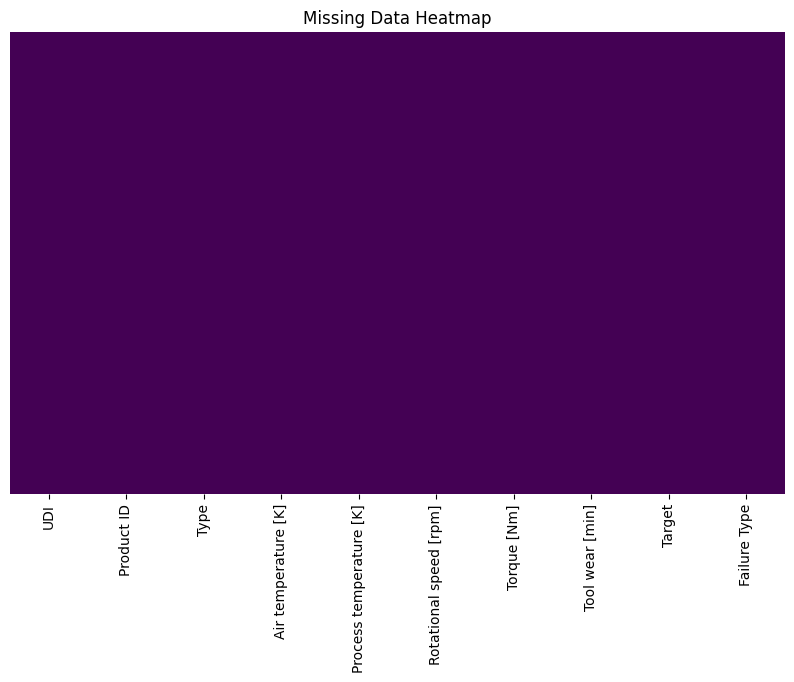

Missing percentage per column:


Series([], dtype: float64)

In [43]:
# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Percentage of missing values per column
missing_perc = df.isnull().sum() / len(df) * 100
print("Missing percentage per column:")
display(missing_perc[missing_perc > 0].sort_values(ascending=False))

### Step 1.3: Handling missing data
By analyzing the generated heat map, we can verify that the dataset is completely full with data, eliminating the need to use techniques to handle missing data.

However, it is essential to know some techniques for handling missing data:
* **Data Removal:** This method is used when there is a large number of columns or rows with empty and null values.
* **Data Imputation:** This method is used when there is a critical column or row where missing values ​​must be entered using measures of central tendency.
* **Forward/Backward Fill:** This method is used when there is a critical column or row where missing values ​​need to be filled in using time series.

### Step 1.4: Identifying duplicates
It is also important to remove duplicate values ​​from a dataset, as this can bias it with repeated data. Therefore, we need to detect duplicate values ​​in our dataset.

In [44]:
# Identify duplicates
dup_data = pd.read_csv('raw\predictive_maintenance.csv')
exact_dups = dup_data.duplicated()
print("Duplicate rows (exact):")
display(dup_data[exact_dups])

Duplicate rows (exact):


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type


From this code, we can see that our dataset does not contain duplicate data, so duplicate removal methods are not necessary.

### Step 1.5: Removing desnecessary columns
Removing unique columns (i.e., columns that store IDs) is essential to reduce interference during the machine learning process, since such columns don't add much value.

In addition to removing the ID columns, it is crucial to remove one of the target columns, which in the case of the dataset are: "Target" and "Failure Type". In our case, we want to predict why a machine failed, not just whether it failed or not. Therefore, we will choose to remove the "Target" column to avoid data leakage -- which can hinder the machine learning phase.


In [45]:
# Drop ID columns
df_clean = df.drop(columns=["UDI","Product ID", "Target"])

### Step 1.6: Identifying outliers

First, we will look for outliers, that is, extreme values ​​that may originate from measurement errors and that may bias our dataset.

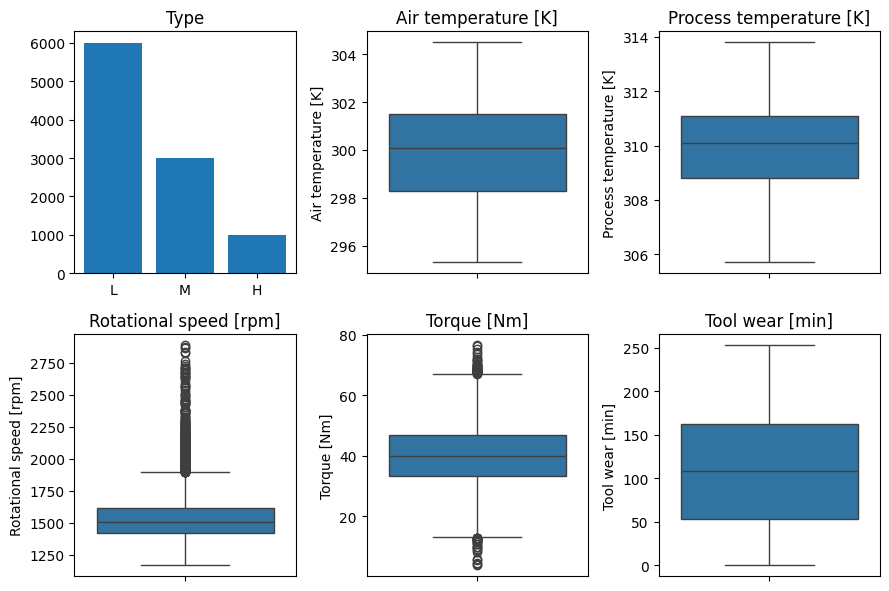

In [46]:
import math
n = len(df_clean.columns)
n_cols = 3
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 3))
for i, col in enumerate(df_clean.columns, 1):
    if col in ["Failure Type"]:
        continue
    plt.subplot(n_rows, n_cols, i)

    if df_clean[col].dtype in ['int64', 'float64']:
        sns.boxplot(df_clean[col])
    else:
        plt.bar(df_clean[col].value_counts().index, df_clean[col].value_counts().values)

    plt.title(col)
plt.tight_layout()
plt.show()

Each dot represents an outlier that deviates from the set of expected values ​​(represented by the blue bar). 

However, when we analyze the dataset as a whole, we see that these outliers are normal, since they're indicators of machine failure. Therefore, we will not remove them.

### Step 1.7: Data transformation
Finally, to ensure that our model training is efficient, we must transform our categorical columns into numeric columns. To do this, we will use two types of encoding:

* **Label encoding:** This is used through manual mapping. It is used when we only want to transform the values ​​of a categorical column. However, this type of encoding can bias the training process because the values ​​may be interpreted by the machine as categories that have greater importance than others (0, 1, 2, ...). Therefore, we will use this type of encoding in our 'Failure Type' column, as it makes sense to have an order (from the least severe problem to the worst possible problem).

In [47]:
print(df["Failure Type"].unique())

<StringArray>
[              'No Failure',            'Power Failure',
        'Tool Wear Failure',       'Overstrain Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


In [48]:
failure_map = {'No Failure': 0,
              'Power Failure': 1,
              'Overstrain Failure': 2,
              'Heat Dissipation Failure': 3,
              'Tool Wear Failure': 4,
              'Random Failures': 5}
df_clean['Failure Type'] = df_clean['Failure Type'].map(failure_map)

* **One-hot encoding:** in contrast to label encoding, this involves creating a column for each category, eliminating the idea of ​​a hierarchy of importance between categories. We will use this in the 'Type' column, as it doesn't make sense for a machine of type *L* to have more importance than a machine of type *M*, and so on.

In [49]:
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

### Step 1.8: Separation
It is crucial to separate the columns that can be selected during the Feature Selection process from the target column. This way, to avoid data leakage in the future, we will insert the non-target columns into the variable y and the target column into the variable X.

In [50]:
X = df_clean.drop(columns=["Failure Type"])
y = df_clean["Failure Type"]
clean_path = "data/clean_data.csv"
df_clean.to_csv(clean_path, index=False)